In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

from tqdm import tqdm
import json
import time
import os

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
df = pd.read_parquet("Data/dipser_dataset.parquet", engine="pyarrow")
df["age_group"] = pd.cut(df["age"], bins=[13, 20, 22, 26, 44]) # bins=[13, 17, 20, 22, 26, 44]
df.head()

,group,time,time_sec,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,gender,age,race,subject_experiment_id,attention,subject_id,age_group
0,group01,2026-05-08 10:40:43.047895,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,"(22, 26]"
1,group01,2026-05-08 10:40:43.195317,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_195317.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_195317.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109485,0.000109,-0.660015,0.000520,0.632620,0.000426,0.390106,0.000225,246.0,0.0,-0.004508,0.005235,-0.004068,0.003267,-0.001026,0.005944,0.053056,0.036979,-0.124020,0.045047,0.012282,0.043478,63.0,0.0,78.0,NaN,0.148634,0.038779,0.009572,0.004378,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,"(22, 26]"
2,group01,2026-05-08 10:40:43.295405,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_295405.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_295405.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109478,0.000101,-0.660194,0.000514,0.632473,0.000406,0.390043,0.000252,246.0,0.0,-0.004581,0.005193,-0.003897,0.003153,-0.000525,0.005644,0.054420,0.036670,-0.129478,0.044805,0.015730,0.040968,63.0,0.0,78.0,NaN,0.153129,0.038995,0.009384,0.004079,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,"(22, 26]"
3,group01,2026-05-08 10:40:43.395835,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_395835.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_395835.json,subject_01,experime

In [3]:
df.shape

(889685, 69)

In [4]:
SEED = 42
SEQUENCE_LENGTH = 10
MAX_MISSING_VISUAL_FRAMES = 4

# Label-imbalance intervention toggles.
USE_WEIGHTED_LOSS = True
USE_WEIGHTED_SAMPLER = False
WEIGHT_ALPHA = 0.5       # 0=no weighting, 1=full inverse-frequency weighting
STRATIFY_COLUMN = 'age_group'

# ATTENTION_BINS = [2, 2.5, 3, 3.5, 4, 4.75]
ATTENTION_BINS = [2, 2.5, 3, 3.5, 4.75]

In [5]:
df[['attention', 'image_path', 'age', 'gender']].isna().sum()

attention     0
image_path    0
age           0
gender        0
dtype: int64

In [6]:
sensor_cols = [
    col for col in df.columns
    if (
       # "sensor" in col.lower()
        "acceleration" in col.lower()
        or "gyro" in col.lower()
      #  or "rotation" in col.lower()
        or "heart" in col.lower()
      #  or "light" in col.lower()
        or "accel" in col.lower()
    )
    and "std" not in col.lower()
]

# Heart rate is physiologically different from motion/device sensors, so Fusion
# follows Temporal Sensor and gives it a separate projection stream.
hr_cols = ["heart_rate"] if "heart_rate" in sensor_cols else []
motion_cols = [col for col in sensor_cols if col not in hr_cols]
hr_indices = [sensor_cols.index(col) for col in hr_cols]
motion_indices = [sensor_cols.index(col) for col in motion_cols]

len(sensor_cols), len(motion_cols), len(hr_cols), sensor_cols[:5]

(9,
 8,
 1,
 ['lsm6dso_gyroscope value0_mean',
  'lsm6dso_gyroscope value1_mean',
  'lsm6dso_gyroscope value2_mean',
  'samsung_linear_acceleration_sensor value0_mean',
  'samsung_linear_acceleration_sensor value1_mean'])

In [7]:
# Treat physiologically impossible HR values as missing before missing flags and scaling.
# The smartwatch can emit 0, which should not be interpreted as a real heart rate.
df.loc[df["heart_rate"] < 30, "heart_rate"] = np.nan

df[sensor_cols] = df[sensor_cols].astype(np.float32)

In [8]:
# keep only 1 frame per second (the first)
df_sec = (df.sort_values(["subject_experiment_id", "time_sec"])
      .groupby(["subject_experiment_id", "time_sec"])
      .first()
      .reset_index())
df_sec.shape

(111754, 69)

In [9]:
reconstructed_sequences = []

for sequence_id, sequence_df in df_sec.groupby("subject_experiment_id"):
    sequence_df = sequence_df.sort_values("time_sec")

    complete_seconds = pd.DataFrame({
        "time_sec": np.arange(
            sequence_df["time_sec"].min(),
            sequence_df["time_sec"].max() + 1
        )
    })

    reconstructed = complete_seconds.merge(
        sequence_df,
        on="time_sec",
        how="left"
    )

    reconstructed["subject_experiment_id"] = sequence_id
    reconstructed_sequences.append(reconstructed)

temporal_frame_dataset = pd.concat(reconstructed_sequences, ignore_index=True)

sequence_metadata = (
    df[["subject_experiment_id", "subject_id", "gender", "age"]]
    .drop_duplicates("subject_experiment_id"))

# Restore metadata for reconstructed missing seconds. Sensor/image/target values
# stay missing unless observed, so missingness flags remain meaningful.
temporal_frame_dataset = temporal_frame_dataset.drop(
    columns=["subject_id", "gender", "age"],
    errors="ignore").merge(sequence_metadata, on="subject_experiment_id", how="left")

temporal_frame_dataset["visual_missing"] = temporal_frame_dataset["image_path"].isna().astype(np.float32)
temporal_frame_dataset["motion_missing"] = temporal_frame_dataset[motion_cols].isna().all(axis=1).astype(np.float32)
temporal_frame_dataset["hr_missing"] = temporal_frame_dataset[hr_cols].isna().all(axis=1).astype(np.float32) if hr_cols else 1.0
temporal_frame_dataset["sensor_missing"] = temporal_frame_dataset[sensor_cols].isna().all(axis=1).astype(np.float32)
temporal_frame_dataset["sensor_partial_nan"] = (
    temporal_frame_dataset[sensor_cols].isna().any(axis=1)
    & ~temporal_frame_dataset[sensor_cols].isna().all(axis=1)
).astype(np.float32)

temporal_frame_dataset[["subject_experiment_id", "time_sec", "visual_missing", "motion_missing", "hr_missing", "sensor_missing", "attention"]].head()

,subject_experiment_id,time_sec,visual_missing,motion_missing,hr_missing,sensor_missing,attention
0,group01_experiment01_subject_01,0,0.0,0.0,0.0,0.0,3.25
1,group01_experiment01_subject_01,1,0.0,0.0,0.0,0.0,3.00
2,group01_experiment01_subject_01,2,0.0,0.0,0.0,0.0,3.00
3,group01_experiment01_subject_01,3,0.0,0.0,0.0,0.0,3.25
4,group01_experiment01_subject_01,4,0.0,0.0,0.0,0.0,3.25


In [10]:
temporal_frame_dataset.shape

(121631, 74)

In [11]:
# feature_index = pd.read_parquet("Data/resnet50_features/resnet50_frame_index.parquet")
# feature_store_path = "Data/resnet50_features/resnet50_frame_features.npy"
# VISUAL_FEATURE_DIM = 2048

# feature_index = pd.read_parquet('Data/All_clip_vitl14_features/All_clip_vitl14_frame_index.parquet')
# feature_store_path =  'Data/All_clip_vitl14_features/All_clip_vitl14_frame_features.npy'
# VISUAL_FEATURE_DIM = 768

feature_index = pd.read_parquet('Data/clip_vitl14_features/clip_vitl14_frame_index.parquet')
feature_store_path =  'Data/clip_vitl14_features/clip_vitl14_frame_features.npy'
VISUAL_FEATURE_DIM = 768

feature_row_by_path = dict(zip(feature_index["image_path"], feature_index["feature_row"]))
CNN_FEATURES = feature_store_path.split('/')[-2]

temporal_frame_dataset["feature_row"] = (
    temporal_frame_dataset["image_path"]
    .map(feature_row_by_path)
    .fillna(-1)
    .astype(np.int64)
)

missing_feature_rows = (
    (temporal_frame_dataset["visual_missing"] == 0)
    & (temporal_frame_dataset["feature_row"] == -1)
).sum()
print("Non-missing image rows without cached features:", missing_feature_rows)

Non-missing image rows without cached features: 0


In [12]:
temporal_frame_dataset

,time_sec,subject_experiment_id,group,time,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,race,attention,age_group,subject_id,gender,age,visual_missing,motion_missing,hr_missing,sensor_missing,sensor_partial_nan,feature_row
0,0,group01_experiment01_subject_01,group01,2026-05-08 10:40:43.047895,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,white,3.25,"(22, 26]",group01_subject_01,male,26.0,0.0,0.0,0.0,0.0,0.0,0
1,1,group01_experiment01_subject_01,group01,2026-05-08 10:40:44.195980,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_44_195980.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_44_195980.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,3.0,3.0,1.0,3.0,9.0,3.0,1.0,7.0,-0.109484,0.000186,-0.663393,0.001822,0.629769,0.001544,0.388982,0.000659,246.0,0.0,-0.017314,0.012752,-0.005738,0.003119,-0.002246,0.006452,0.055115,0.038306,-0.129263,0.050346,0.014268,0.035097,63.0,0.0,77.0,NaN,0.152183,0.044628,0.020409,0.011592,NaN,NaN,NaN,NaN,valid,white,3.00,"(22, 26]",group01_subject_01,male,26.0,0.0,0.0,0.0,0.0,0.0,1
2,2,group01_experiment01_subject_01,group01,2026-05-08 10:40:45.095651,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_45_095651.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_45_095651.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,3.0,3.0,1.0,3.0,9.0,3.0,1.0,7.0,-0.109878,0.000156,-0.667409,0.000379,0.626474,0.000320,0.387325,0.000218,246.0,0.0,-0.003115,0.007570,-0.002407,0.002732,-0.001051,0.007162,0.053606,0.034863,-0.129119,0.055241,0.013599,0.039643,63.0,0.0,77.0,NaN,0.152138,0.048870,0.010279,0.005109,NaN,NaN,NaN,NaN,valid,white,3.00,"(22, 26]",group01_subject_01,male,26.0,0.0,0.0,0.0,0.0,0.0,2
3,3,group01_experiment01_subject_01,group01,2026-05-08 10:40:46.641389,/home/cfragkiadakis/prjs203

In [13]:
subject_df = temporal_frame_dataset[["subject_id", STRATIFY_COLUMN]].dropna(subset='age_group').drop_duplicates()

train_sub, temp_sub = train_test_split(
    subject_df,
    test_size=0.3,
    stratify=subject_df[STRATIFY_COLUMN],
    random_state=SEED
)

val_sub, test_sub = train_test_split(
    temp_sub,
    test_size=0.5,
    stratify=temp_sub[STRATIFY_COLUMN],
    random_state=SEED
)

train_subjects = train_sub["subject_id"]
val_subjects = val_sub["subject_id"]
test_subjects = test_sub["subject_id"]

train_frames = temporal_frame_dataset[temporal_frame_dataset["subject_id"].isin(train_subjects)].copy()
val_frames = temporal_frame_dataset[temporal_frame_dataset["subject_id"].isin(val_subjects)].copy()
test_frames = temporal_frame_dataset[temporal_frame_dataset["subject_id"].isin(test_subjects)].copy()

# Train-only sensor normalization. Missing values become 0 after standardization;
# motion/hr missing flags tell the model which modality was absent at that timestep.
sensor_means = train_frames.loc[train_frames["sensor_missing"] == 0, sensor_cols].mean()
sensor_stds = train_frames.loc[train_frames["sensor_missing"] == 0, sensor_cols].std()
sensor_stds = sensor_stds.replace(0, np.nan).fillna(1.0)
sensor_means = sensor_means.fillna(0.0)


def apply_sensor_scaling(frame_df):
    frame_df = frame_df.copy()
    scaled = ((frame_df[sensor_cols] - sensor_means) / sensor_stds).astype(np.float32)
    scaled = scaled.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    scaled.loc[frame_df["sensor_missing"] == 1, :] = 0.0

    # Keep each sensor as its own column instead of packing all sensors into
    # one object-valued sensor_vector column. This keeps the sequence dataframe
    # inspectable and aligned with the original df column structure.
    frame_df.loc[:, sensor_cols] = scaled.to_numpy(dtype=np.float32)
    return frame_df


train_frames = apply_sensor_scaling(train_frames)
val_frames = apply_sensor_scaling(val_frames)
test_frames = apply_sensor_scaling(test_frames)

MOTION_INPUT_DIM = len(motion_cols) + 1  # +1 for motion_missing flag
HR_INPUT_DIM = len(hr_cols) + 1          # +1 for hr_missing flag
SENSOR_INPUT_DIM = len(sensor_cols) + 1

pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(train_frames), len(val_frames), len(test_frames)],
    "subjects": [train_frames.subject_id.nunique(), val_frames.subject_id.nunique(), test_frames.subject_id.nunique()],
    "target_mean": [train_frames.attention.mean(), val_frames.attention.mean(), test_frames.attention.mean()],
    "visual_missing_rate": [train_frames.visual_missing.mean(), val_frames.visual_missing.mean(), test_frames.visual_missing.mean()],
    "motion_missing_rate": [train_frames.motion_missing.mean(), val_frames.motion_missing.mean(), test_frames.motion_missing.mean()],
    "hr_missing_rate": [train_frames.hr_missing.mean(), val_frames.hr_missing.mean(), test_frames.hr_missing.mean()],
    "sensor_missing_rate": [train_frames.sensor_missing.mean(), val_frames.sensor_missing.mean(), test_frames.sensor_missing.mean()],
    "sensor_partial_nan_rate": [train_frames.sensor_partial_nan.mean(), val_frames.sensor_partial_nan.mean(), test_frames.sensor_partial_nan.mean()],
})

,split,rows,subjects,target_mean,visual_missing_rate,motion_missing_rate,hr_missing_rate,sensor_missing_rate,sensor_partial_nan_rate
0,train,82012,39,2.937818,0.088170,0.088170,0.106728,0.088170,0.018558
1,val,19345,9,3.010811,0.067563,0.067563,0.071078,0.067563,0.003515
2,test,20274,9,2.948997,0.066045,0.066045,0.068314,0.066045,0.002269


In [14]:
def create_temporal_sequences(frame_df, sequence_length=SEQUENCE_LENGTH):
    sequences = []

    for sequence_id, sequence_df in frame_df.groupby("subject_experiment_id"):
        sequence_df = sequence_df.sort_values("time_sec").reset_index(drop=True)

        if len(sequence_df) < sequence_length:
            continue

        for i in range(sequence_length - 1, len(sequence_df)):
            target = sequence_df.iloc[i]["attention"]

            if pd.isna(target):
                continue

            history = sequence_df.iloc[i - sequence_length + 1:i + 1]
            visual_missing_flags = history["visual_missing"].astype(np.float32).values

            if visual_missing_flags.sum() > MAX_MISSING_VISUAL_FRAMES:
                continue

            motion_missing_flags = history["motion_missing"].astype(np.float32).values
            hr_missing_flags = history["hr_missing"].astype(np.float32).values
            sensor_missing_flags = history["sensor_missing"].astype(np.float32).values

            sequence_record = {
                "subject_experiment_id": sequence_id,
                "subject_id": sequence_df.iloc[i]["subject_id"],
                "gender": sequence_df.iloc[i]["gender"],
                "age": sequence_df.iloc[i]["age"],
                "time_sec": int(sequence_df.iloc[i]["time_sec"]),
                "feature_rows": history["feature_row"].tolist(),
                "visual_missing_flags": visual_missing_flags.tolist(),
                "motion_missing_flags": motion_missing_flags.tolist(),
                "hr_missing_flags": hr_missing_flags.tolist(),
                "sensor_missing_flags": sensor_missing_flags.tolist(),
                "target": float(target),
            }

            # Store every scaled sensor as its own temporal column. Each value is
            # a length-SEQUENCE_LENGTH list, e.g. train_df["heart_rate"].iloc[0].
            for sensor_col in sensor_cols:
                sequence_record[sensor_col] = (
                    history[sensor_col]
                    .astype(np.float32)
                    .to_numpy(dtype=np.float32)
                    .tolist()
                )

            sequences.append(sequence_record)

    return pd.DataFrame(sequences)

In [15]:
train_df = create_temporal_sequences(train_frames)
val_df = create_temporal_sequences(val_frames)
test_df = create_temporal_sequences(test_frames)

pd.DataFrame({
    "split": ["train", "val", "test"],
    "sequences": [len(train_df), len(val_df), len(test_df)],
    "subjects": [train_df.subject_id.nunique(), val_df.subject_id.nunique(), test_df.subject_id.nunique()],
    "target_mean": [train_df.target.mean(), val_df.target.mean(), test_df.target.mean()],
})

,split,sequences,subjects,target_mean
0,train,70966,39,2.938231
1,val,17258,9,3.012719
2,test,18222,9,2.950239


### Train Test Split

In [16]:
class MultimodalFusionDataset(Dataset):

    def __init__(self, sequence_df, feature_store_path):
        self.df = sequence_df.reset_index(drop=True)
        self.feature_store_path = feature_store_path
        self.feature_store = None

    def __len__(self):
        return len(self.df)

    def _features(self):
        if self.feature_store is None:
            self.feature_store = np.load(self.feature_store_path, mmap_mode="r")
        return self.feature_store

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        feature_rows = np.asarray(row["feature_rows"], dtype=np.int64)
        visual_features = np.zeros((len(feature_rows), VISUAL_FEATURE_DIM), dtype=np.float32)

        valid = feature_rows >= 0
        visual_features[valid] = self._features()[feature_rows[valid]]

        # Reconstruct the T x sensor_dim tensor from separate temporal sensor
        # columns instead of reading one packed sensor_values column.
        sensors = np.stack(
            [
                np.asarray(row[sensor_col], dtype=np.float32)
                for sensor_col in sensor_cols
            ],
            axis=1
        )
        sensors = torch.tensor(sensors, dtype=torch.float32)
        sensors = torch.nan_to_num(sensors, nan=0.0, posinf=0.0, neginf=0.0)

        motion = sensors[:, motion_indices]
        motion_missing = torch.tensor(row["motion_missing_flags"], dtype=torch.float32).unsqueeze(-1)
        motion = torch.cat([motion, motion_missing], dim=-1)

        if hr_indices:
            heart_rate = sensors[:, hr_indices]
        else:
            heart_rate = torch.zeros((sensors.shape[0], 0), dtype=torch.float32)
        hr_missing = torch.tensor(row["hr_missing_flags"], dtype=torch.float32).unsqueeze(-1)
        heart_rate = torch.cat([heart_rate, hr_missing], dim=-1)

        visual_features = torch.tensor(visual_features, dtype=torch.float32)
        visual_missing_flags = torch.tensor(row["visual_missing_flags"], dtype=torch.float32)
        target = torch.tensor(row["target"], dtype=torch.float32)
        sample_weight = torch.tensor(row["sample_weight"], dtype=torch.float32)

        return visual_features, motion, heart_rate, visual_missing_flags, target, sample_weight, idx

In [17]:
# Quantify target imbalance and create inverse-frequency train weights.
# Weights are learned from train only; val/test weights are diagnostic only.
def add_attention_bin_weights(alpha, train_df, val_df, test_df):
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_bins = pd.cut(train_df["target"], bins=ATTENTION_BINS, include_lowest=True)
    bin_counts = train_bins.value_counts().sort_index()
    nonzero_counts = bin_counts[bin_counts > 0]

    bin_weights = (len(train_df) / (len(nonzero_counts) * nonzero_counts)) ** alpha

    for split_df in [train_df, val_df, test_df]:
        split_bins = pd.cut(split_df["target"], bins=ATTENTION_BINS, include_lowest=True)
        split_df["attention_bin"] = split_bins.astype(str)
        split_df["sample_weight"] = split_bins.map(bin_weights).astype(float).fillna(1.0)

    train_weight_mean = train_df["sample_weight"].mean()

    for split_df in [train_df, val_df, test_df]:
        split_df["sample_weight"] = split_df["sample_weight"] / train_weight_mean

    normalized_bin_weights = bin_weights / train_weight_mean

    imbalance_table = pd.DataFrame({
        "bin": bin_counts.index.astype(str),
        "train_count": bin_counts.values,
        "weight": [
            float(normalized_bin_weights.get(idx, np.nan))
            for idx in bin_counts.index
        ],
    })

    return train_df, val_df, test_df, imbalance_table

train_df, val_df, test_df, imbalance_table = add_attention_bin_weights(WEIGHT_ALPHA, train_df, val_df, test_df)
display(imbalance_table)

pd.DataFrame({
    "split": ["train", "val", "test"],
    "sequences": [len(train_df), len(val_df), len(test_df)],
    "subjects": [train_df.subject_id.nunique(), val_df.subject_id.nunique(), test_df.subject_id.nunique()],
    "target_mean": [train_df.target.mean(), val_df.target.mean(), test_df.target.mean()],
    "mean_sample_weight": [train_df.sample_weight.mean(), val_df.sample_weight.mean(), test_df.sample_weight.mean()],
})

,bin,train_count,weight
0,"(1.999, 2.5]",16042,1.107837
1,"(2.5, 3.0]",34752,0.752688
2,"(3.0, 3.5]",15550,1.125226
3,"(3.5, 4.75]",4622,2.063907


,split,sequences,subjects,target_mean,mean_sample_weight
0,train,70966,39,2.938231,1.000000
1,val,17258,9,3.012719,1.027176
2,test,18222,9,2.950239,0.992589


In [23]:
train_df.shape, val_df.shape, test_df.shape

((70966, 22), (17258, 22), (18222, 22))

In [26]:
len(set(train_df['subject_experiment_id'])), len(set(val_df['subject_experiment_id'])) ,len(set(test_df['subject_experiment_id']))

(275, 65, 68)

In [18]:
train_dataset = MultimodalFusionDataset(train_df, feature_store_path)
val_dataset = MultimodalFusionDataset(val_df, feature_store_path)
test_dataset = MultimodalFusionDataset(test_df, feature_store_path)

if USE_WEIGHTED_SAMPLER:
    sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(train_df["sample_weight"].values, dtype=torch.double),
        num_samples=len(train_df),
        replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

else:
    train_loader = DataLoader(train_dataset, batch_size=32, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

### Training

In [19]:
# class MultimodalFusionTransformer(nn.Module):

#     def __init__(
#         self,
#         motion_input_dim,
#         hr_input_dim,
#         max_seq_len=SEQUENCE_LENGTH,
#         visual_feature_dim=VISUAL_FEATURE_DIM,
#         embed_dim=256,
#         num_heads=4,
#         num_layers=2,
#         dropout=0.2
#     ):
#         super().__init__()

#         self.max_seq_len = max_seq_len
#         self.num_modalities = 3

#         self.visual_projection = nn.Sequential(
#             nn.Linear(visual_feature_dim + 1, embed_dim),
#             nn.LayerNorm(embed_dim),
#             nn.ReLU(),
#             nn.Dropout(dropout)
#         )

#         self.motion_projection = nn.Sequential(
#             nn.Linear(motion_input_dim, 128),
#             nn.LayerNorm(128),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(128, embed_dim),
#             nn.LayerNorm(embed_dim),
#             nn.ReLU()
#         )

#         self.hr_projection = nn.Sequential(
#             nn.Linear(hr_input_dim, 32),
#             nn.LayerNorm(32),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(32, embed_dim),
#             nn.LayerNorm(embed_dim),
#             nn.ReLU()
#         )

#         self.time_embedding = nn.Parameter(torch.zeros(max_seq_len, embed_dim))
#         self.modality_embedding = nn.Parameter(torch.zeros(self.num_modalities, embed_dim))

#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=embed_dim,
#             nhead=num_heads,
#             dim_feedforward=512,
#             dropout=dropout,
#             batch_first=True
#         )

#         self.transformer = nn.TransformerEncoder(
#             encoder_layer,
#             num_layers=num_layers
#         )

#         # Learned modality pooling over final-step visual/motion/HR tokens.
#         self.modality_pool = nn.Sequential(
#             nn.Linear(embed_dim, 64),
#             nn.Tanh(),
#             nn.Linear(64, 1)
#         )

#         self.regressor = nn.Sequential(
#             nn.Linear(embed_dim, 128),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(128, 1)
#         )

#     def forward(self, visual_features, motion, heart_rate, visual_missing_flags):
#         B, T, _ = visual_features.shape

#         visual_missing_flags = visual_missing_flags.unsqueeze(-1)
#         visual_features = torch.cat([visual_features, visual_missing_flags], dim=-1)

#         visual_tokens = self.visual_projection(visual_features)
#         motion_tokens = self.motion_projection(motion)
#         hr_tokens = self.hr_projection(heart_rate)

#         modality_tokens = torch.stack(
#             [visual_tokens, motion_tokens, hr_tokens],
#             dim=2
#         )  # B, T, 3, D

#         time_emb = self.time_embedding[:T].view(1, T, 1, -1)
#         modality_emb = self.modality_embedding.view(1, 1, self.num_modalities, -1)
#         modality_tokens = modality_tokens + time_emb + modality_emb

#         fused_tokens = modality_tokens.reshape(B, T * self.num_modalities, -1)

#         token_times = torch.arange(T, device=visual_features.device).repeat_interleave(self.num_modalities)
#         causal_mask = token_times.unsqueeze(0) > token_times.unsqueeze(1)

#         fused_tokens = self.transformer(
#             fused_tokens,
#             mask=causal_mask
#         )

#         final_step_tokens = fused_tokens[:, -self.num_modalities:, :]  # B, 3, D

#         pool_scores = self.modality_pool(final_step_tokens)            # B, 3, 1
#         pool_weights = torch.softmax(pool_scores, dim=1)               # B, 3, 1
#         final_token = (final_step_tokens * pool_weights).sum(dim=1)    # B, D

#         prediction = self.regressor(final_token)
#         return prediction.squeeze(1)

In [20]:
class MultimodalLateFusionTransformer(nn.Module):

    def __init__(
        self,
        motion_input_dim,
        hr_input_dim,
        max_seq_len=SEQUENCE_LENGTH,
        visual_feature_dim=VISUAL_FEATURE_DIM,
        embed_dim=256,
        num_heads=4,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.max_seq_len = max_seq_len

        self.visual_projection = nn.Sequential(
            nn.Linear(visual_feature_dim + 1, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.motion_projection = nn.Sequential(
            nn.Linear(motion_input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU()
        )

        self.hr_projection = nn.Sequential(
            nn.Linear(hr_input_dim, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU()
        )

        self.time_embedding = nn.Parameter(torch.zeros(max_seq_len, embed_dim))

        visual_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True
        )

        sensor_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=512,
            dropout=dropout,
            batch_first=True
        )

        self.visual_encoder = nn.TransformerEncoder(
            visual_layer,
            num_layers=num_layers
        )

        self.motion_encoder = nn.TransformerEncoder(
            sensor_layer,
            num_layers=1
        )

        self.hr_encoder = nn.TransformerEncoder(
            sensor_layer,
            num_layers=1
        )

        self.fusion_gate = nn.Sequential(
            nn.Linear(embed_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 3)
        )

        self.regressor = nn.Sequential(
            nn.Linear(embed_dim * 3, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, visual_features, motion, heart_rate, visual_missing_flags):
        B, T, _ = visual_features.shape

        visual_missing_flags = visual_missing_flags.unsqueeze(-1)
        visual_features = torch.cat([visual_features, visual_missing_flags], dim=-1)

        time_emb = self.time_embedding[:T].unsqueeze(0)

        visual_tokens = self.visual_projection(visual_features) + time_emb
        motion_tokens = self.motion_projection(motion) + time_emb
        hr_tokens = self.hr_projection(heart_rate) + time_emb

        token_times = torch.arange(T, device=visual_features.device)
        causal_mask = token_times.unsqueeze(0) > token_times.unsqueeze(1)

        visual_encoded = self.visual_encoder(visual_tokens, mask=causal_mask)
        motion_encoded = self.motion_encoder(motion_tokens, mask=causal_mask)
        hr_encoded = self.hr_encoder(hr_tokens, mask=causal_mask)

        visual_summary = visual_encoded[:, -1, :]
        motion_summary = motion_encoded[:, -1, :]
        hr_summary = hr_encoded[:, -1, :]

        summaries = torch.stack(
            [visual_summary, motion_summary, hr_summary],
            dim=1
        )  # B, 3, D

        fusion_input = torch.cat(
            [visual_summary, motion_summary, hr_summary],
            dim=1
        )  # B, 3D

        gate_logits = self.fusion_gate(fusion_input)          # B, 3
        gate_weights = torch.softmax(gate_logits, dim=1)      # B, 3

        gated_summaries = summaries * gate_weights.unsqueeze(-1)
        final_token = gated_summaries.reshape(B, -1)          # B, 3D

        prediction = self.regressor(final_token)
        return prediction.squeeze(1)

In [21]:
def train_one_epoch(model, loader):

    model.train()
    total_loss = 0
    preds_all = []
    labels_all = []
    pbar = tqdm(loader, desc="Training", leave=False)

    for visual_features, motion, heart_rate, visual_missing_flags, labels, sample_weights, idx in pbar:
        visual_features = visual_features.to(device)
        motion = motion.to(device)
        heart_rate = heart_rate.to(device)
        visual_missing_flags = visual_missing_flags.to(device)
        labels = labels.to(device)
        sample_weights = sample_weights.to(device)

        preds = model(visual_features, motion, heart_rate, visual_missing_flags)
        per_sample_loss = criterion(preds, labels)

        if USE_WEIGHTED_LOSS:
            loss = (per_sample_loss * sample_weights).sum() / sample_weights.sum()
        else:
            loss = per_sample_loss.mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

In [22]:
def evaluate(model, loader):

    model.eval()
    preds_all = []
    labels_all = []
    inference_times = []
    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for visual_features, motion, heart_rate, visual_missing_flags, labels, sample_weights, idx in pbar:
            visual_features = visual_features.to(device)
            motion = motion.to(device)
            heart_rate = heart_rate.to(device)
            visual_missing_flags = visual_missing_flags.to(device)
            labels = labels.to(device)

            start = time.time()
            preds = model(visual_features, motion, heart_rate, visual_missing_flags)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    mae = mean_absolute_error(labels_all, preds_all)
    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return mae, rmse, np.mean(inference_times)

In [23]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, model_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None
        self.best_epoch = None
        self.model_path = model_path

    def step(self, metric, model, epoch):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0

            self.best_model = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch

            if self.model_path is not None:
                torch.save(self.best_model, self.model_path)

            return False  # continue

        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            return self.counter >= self.patience

In [24]:
LOSS_TYPE = 'mse' # options: "smooth_l1", "mse", "l1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalLateFusionTransformer(
    motion_input_dim=MOTION_INPUT_DIM,
    hr_input_dim=HR_INPUT_DIM,
    max_seq_len=SEQUENCE_LENGTH,
    visual_feature_dim=VISUAL_FEATURE_DIM,
    embed_dim=256,
    num_heads=4,
    num_layers=2,
    dropout=0.2
).to(device)

if LOSS_TYPE == "smooth_l1":
    criterion = nn.SmoothL1Loss(beta=0.5, reduction="none")
    EARLY_STOPPING_METRIC = "mae"
elif LOSS_TYPE == "mse":
    criterion = nn.MSELoss(reduction="none")
    EARLY_STOPPING_METRIC = "rmse"
elif LOSS_TYPE == "l1":
    criterion = nn.L1Loss(reduction="none")
    EARLY_STOPPING_METRIC = "mae"
else:
    raise ValueError(f"Unknown LOSS_TYPE: {LOSS_TYPE}")

print(f"Loss type: {LOSS_TYPE}")
print(f"Early stopping / checkpoint metric: validation {EARLY_STOPPING_METRIC.upper()}")

learning_rate = 1e-4
weight_decay = 1e-5


optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=3)

Loss type: mse
Early stopping / checkpoint metric: validation RMSE


In [25]:
name = f"245.fusion_split_hr_transformer_{LOSS_TYPE}_{CNN_FEATURES}_seq{SEQUENCE_LENGTH}"
if USE_WEIGHTED_LOSS:
    name += f"_weighted_loss_a{WEIGHT_ALPHA}"
if USE_WEIGHTED_SAMPLER:
    name += f"_weighted_sampler_a{WEIGHT_ALPHA}"

model_path = f"models/Multimodal Fusion/{name}.pt"
model_results = f"results/Multimodal Fusion/{name}_results.json"
model_figs = f"figs/Multimodal Fusion/{name}_training_curves.png"
name

'245.fusion_split_hr_transformer_mse_clip_vitl14_features_seq10_weighted_loss_a0.5'

In [26]:
early_stopping = EarlyStopping(patience=7, model_path=model_path)
NUM_EPOCHS = 50
train_losses = []
train_mae_list, train_rmse_list = [], []
val_mae_list, val_rmse_list = [], []
monitor_metric_list = []

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time = evaluate(model, val_loader)

    if EARLY_STOPPING_METRIC == "rmse":
        monitor_value = val_rmse
    elif EARLY_STOPPING_METRIC == "mae":
        monitor_value = val_mae
    else:
        raise ValueError(f"Unknown early stopping metric: {EARLY_STOPPING_METRIC}")

    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)
    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)
    monitor_metric_list.append(monitor_value)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")
    print(f"Checkpoint metric ({EARLY_STOPPING_METRIC.upper()}): {monitor_value:.4f}")

    scheduler.step(monitor_value)
    stop = early_stopping.step(monitor_value, model, epoch)
    best_epoch = early_stopping.best_epoch

    if stop:
        print("Early stopping triggered")
        break

training_end = time.time()
print('Training time:', training_end - training_start)


Epoch 1
Train Loss: 0.2535
Train MAE: 0.3700 | Train RMSE: 0.4853
Val MAE: 0.4068 | Val RMSE: 0.5044
Checkpoint metric (RMSE): 0.5044



Epoch 2
Train Loss: 0.2210
Train MAE: 0.3488 | Train RMSE: 0.4509
Val MAE: 0.3919 | Val RMSE: 0.4902
Checkpoint metric (RMSE): 0.4902



Epoch 3
Train Loss: 0.2156
Train MAE: 0.3434 | Train RMSE: 0.4447
Val MAE: 0.3708 | Val RMSE: 0.4678
Checkpoint metric (RMSE): 0.4678



Epoch 4
Train Loss: 0.2099
Train MAE: 0.3381 | Train RMSE: 0.4381
Val MAE: 0.3787 | Val RMSE: 0.4764
Checkpoint metric (RMSE): 0.4764
EarlyStopping counter: 1/7



Epoch 5
Train Loss: 0.2058
Train MAE: 0.3357 | Train RMSE: 0.4348
Val MAE: 0.3697 | Val RMSE: 0.4680
Checkpoint metric (RMSE): 0.4680
EarlyStopping counter: 2/7


...


Epoch 20
Train Loss: 0.1189
Train MAE: 0.2519 | Train RMSE: 0.3321
Val MAE: 0.3157 | Val RMSE: 0.4245
Checkpoint metric (RMSE): 0.4245
EarlyStopping counter: 3/7



Epoch 21
Train Loss: 0.1166
Train MAE: 0.2492 | Train RMSE: 0.3285
Val MAE: 0.3175 | Val RMSE: 0.4285
Checkpoint metric (RMSE): 0.4285
EarlyStopping counter: 4/7



Epoch 22
Train Loss: 0.1198
Train MAE: 0.2528 | Train RMSE: 0.3304
Val MAE: 0.3279 | Val RMSE: 0.4445
Checkpoint metric (RMSE): 0.4445
EarlyStopping counter: 5/7



Epoch 23
Train Loss: 0.1185
Train MAE: 0.2511 | Train RMSE: 0.3292
Val MAE: 0.3286 | Val RMSE: 0.4445
Checkpoint metric (RMSE): 0.4445
EarlyStopping counter: 6/7



Epoch 24
Train Loss: 0.1159
Train MAE: 0.2475 | Train RMSE: 0.3255
Val MAE: 0.3319 | Val RMSE: 0.4477
Checkpoint metric (RMSE): 0.4477
EarlyStopping counter: 7/7
Early stopping triggered
Training time: 875.2605035305023


### Evaluation

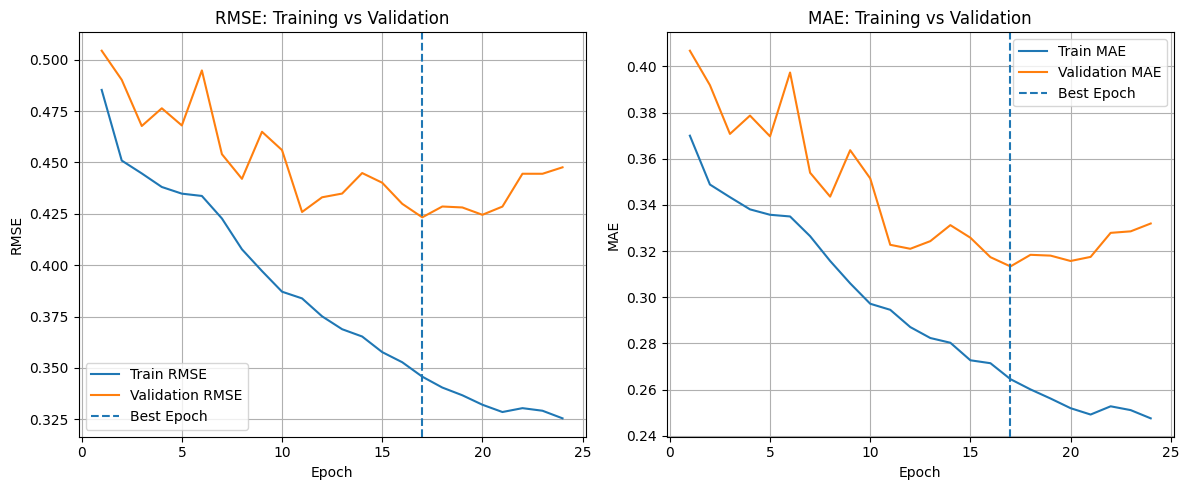

In [27]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig(model_figs, dpi=300, bbox_inches="tight")
plt.show()

In [28]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))

    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group

    return group_mae, worst_group, gap

In [29]:
def collect_predictions(model, df, loader):
    model.eval()

    results = []
    total_time = 0
    total_samples = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")

        for visual_features, motion, heart_rate, visual_missing_flags, labels, sample_weights, idx in pbar:
            visual_features = visual_features.to(device)
            motion = motion.to(device)
            heart_rate = heart_rate.to(device)
            visual_missing_flags = visual_missing_flags.to(device)

            start = time.time()
            preds = model(visual_features, motion, heart_rate, visual_missing_flags)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end = time.time()

            batch_time = end - start
            total_time += batch_time
            total_samples += visual_features.size(0)

            preds = preds.cpu().numpy()

            for i in range(len(preds)):
                row = df.iloc[idx[i].item()]

                results.append({
                    "pred": preds[i],
                    "true": labels[i].item(),
                    "attention_bin": row["attention_bin"],
                    "sample_weight": row["sample_weight"],
                    "gender": row["gender"],
                    "age": row["age"]
                })

    results_df = pd.DataFrame(results)

    mae = np.mean(np.abs(results_df["true"] - results_df["pred"]))
    rmse = np.sqrt(np.mean((results_df["true"] - results_df["pred"])**2))

    latency_per_batch = total_time / len(loader)
    latency_per_sample = total_time / total_samples

    return results_df, mae, rmse, latency_per_batch, latency_per_sample

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, r2_score, roc_auc_score


def compute_fairness_metrics(results_df):
    metrics = {}

    # ---- Gender ----
    gender_mae, gender_worst, gender_gap = compute_group_mae(results_df, "gender")

    metrics["gender"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in gender_mae.items()},
        "worst_group_mae": round(float(gender_worst), 5),
        "gap": round(float(gender_gap), 5)
    }

    # ---- Age ----
    results_df = results_df.copy()
    results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])

    age_mae, age_worst, age_gap = compute_group_mae(results_df, "age_group")

    metrics["age"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in age_mae.items()},
        "worst_group_mae": round(float(age_worst), 5),
        "gap": round(float(age_gap), 5)
    }

    return metrics


def compute_attention_bin_metrics(results_df):
    bin_mae = results_df.groupby("attention_bin").apply(
        lambda x: np.mean(np.abs(x["true"] - x["pred"]))
    )
    bin_count = results_df["attention_bin"].value_counts().sort_index()
    return pd.DataFrame({
        "count": bin_count,
        "mae": bin_mae
    }).sort_index()


def compute_prediction_metrics(results_df, tolerance=0.15, binary_threshold=3.0):
    y_true = results_df["true"].to_numpy(dtype=float)
    y_pred = results_df["pred"].to_numpy(dtype=float)

    binary_true = (y_true >= binary_threshold).astype(int)
    binary_pred = (y_pred >= binary_threshold).astype(int)

    try:
        binary_auc = roc_auc_score(binary_true, y_pred)
    except ValueError:
        binary_auc = np.nan

    return {
        "n_samples": int(len(results_df)),
        "mae": round(float(np.mean(np.abs(y_pred - y_true))), 4),
        "rmse": round(float(np.sqrt(np.mean((y_pred - y_true) ** 2))), 4),
        "r2": round(float(r2_score(y_true, y_pred)), 4),
        "tolerant_accuracy": round(float(np.mean(np.abs(y_pred - y_true) <= tolerance)), 4),
        "tolerance": tolerance,
        "one_off_accuracy": round(float(np.mean(np.abs(np.rint(y_pred) - np.rint(y_true)) <= 1)), 4),
        "binary_threshold": binary_threshold,
        "binary_accuracy": round(float(accuracy_score(binary_true, binary_pred)), 4),
        "binary_f1": round(float(f1_score(binary_true, binary_pred, zero_division=0)), 4),
        "binary_roc_auc": None if np.isnan(binary_auc) else round(float(binary_auc), 4),
        "binary_confusion_matrix": confusion_matrix(binary_true, binary_pred).tolist(),
        "true_mean": round(float(np.mean(y_true)), 4),
        "pred_mean": round(float(np.mean(y_pred)), 4),
    }


def append_experiment_results(results, csv_path, jsonl_path):
    flat_row = {
        "run_id": results["run_id"],
        "experiment_name": results["experiment_name"],
        "created_at": results["created_at"],
        "mae": results["mae"],
        "rmse": results["rmse"],
        "tolerant_accuracy": results["tolerant_accuracy"],
        "binary_accuracy": results["binary_accuracy"],
        "binary_f1": results["binary_f1"],
        "binary_roc_auc": results["binary_roc_auc"],
        "one_off_accuracy": results["one_off_accuracy"],
        "r2": results["r2"],
        "gender_worst_group_mae": results["fairness"]["gender"]["worst_group_mae"],
        "gender_gap": results["fairness"]["gender"]["gap"],
        "gender_mae_per_group": json.dumps(results["fairness"]["gender"]["mae_per_group"], sort_keys=True),
        "age_worst_group_mae": results["fairness"]["age"]["worst_group_mae"],
        "age_gap": results["fairness"]["age"]["gap"],
        "age_mae_per_group": json.dumps(results["fairness"]["age"]["mae_per_group"], sort_keys=True),
        "loss_type": results["loss_type"],
        "cnn_features": results["cnn_features"],
        "sequence_length": results["sequence_length"],
        "stratify": results["stratify"],
        "use_weighted_loss": results["use_weighted_loss"],
        "use_weighted_sampler": results["use_weighted_sampler"],
        "weight_alpha": results["weight_alpha"],
        "best_epoch": results["best_epoch"],
        "training_time_sec": results["training_time_sec"],
        "latency_per_sample_ms": results["latency_per_sample_ms"],
    }

    new_row = pd.DataFrame([flat_row])
    if os.path.exists(csv_path):
        experiment_log = pd.read_csv(csv_path)
        experiment_log = pd.concat([experiment_log, new_row], ignore_index=True, sort=False)
        experiment_log.to_csv(csv_path, index=False)
    else:
        new_row.to_csv(csv_path, index=False)

    with open(jsonl_path, "a") as f:
        f.write(json.dumps(results) + "\n")

In [31]:
name = f"245.fusion_split_hr_transformer_{LOSS_TYPE}_{CNN_FEATURES}_seq{SEQUENCE_LENGTH}"
if USE_WEIGHTED_LOSS:
    name += f"_weighted_loss_a{WEIGHT_ALPHA}"
if USE_WEIGHTED_SAMPLER:
    name += f"_weighted_sampler_a{WEIGHT_ALPHA}"

#name = 'fusion_split_hr_transformer_mse_clip_vitl14_features_weighted_loss_a0.5'

model_path = f"models/Multimodal Fusion/{name}.pt"
model_results = f"results/Multimodal Fusion/{name}_results.json"
model_figs = f"figs/Multimodal Fusion/{name}_training_curves.png"
name

'245.fusion_split_hr_transformer_mse_clip_vitl14_features_seq10_weighted_loss_a0.5'

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalLateFusionTransformer(
    motion_input_dim=MOTION_INPUT_DIM,
    hr_input_dim=HR_INPUT_DIM,
    max_seq_len=SEQUENCE_LENGTH,
    visual_feature_dim=VISUAL_FEATURE_DIM,
    embed_dim=256,
    num_layers=2,
    num_heads=4,
).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

/scratch-local/cfragkiadakis.23092695/ipykernel_1704382/2885446873.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loca

MultimodalLateFusionTransformer(
  (visual_projection): Sequential(
    (0): Linear(in_features=769, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (motion_projection): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (6): ReLU()
  )
  (hr_projection): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=256, bias=True)
    (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (6): ReLU()
  )
  (visual_encoder): TransformerEncoder(

In [33]:
results_df, best_mae, best_rmse, best_latency_batch, best_latency_sample = collect_predictions(model, test_df, test_loader)
fairness_metrics = compute_fairness_metrics(results_df)
attention_bin_metrics = compute_attention_bin_metrics(results_df)
evaluation_metrics = compute_prediction_metrics(results_df)

created_at = time.strftime("%Y-%m-%d %H:%M:%S")
run_id = time.strftime("%Y%m%d_%H%M%S")
results_dir = os.path.dirname(model_results)
os.makedirs(results_dir, exist_ok=True)

results = {
    "run_id": run_id,
    "created_at": created_at,
    "experiment_name": name,
    "model_path": model_path,
    "results_path": model_results,
    **evaluation_metrics,
    "loss_type": LOSS_TYPE,
    "cnn_features": CNN_FEATURES,
    "sequence_length": SEQUENCE_LENGTH,
    'stratify': STRATIFY_COLUMN,
    "max_missing_visual_frames": MAX_MISSING_VISUAL_FRAMES,
    "attention_bins": ATTENTION_BINS,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
    "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
    "weight_alpha": WEIGHT_ALPHA,
    "early_stopping_metric": globals().get("EARLY_STOPPING_METRIC"),
    "best_epoch": None if globals().get("best_epoch") is None else int(best_epoch) + 1,
    "num_epochs_run": len(globals().get("train_losses", [])),
    "learning_rate": globals().get("learning_rate"),
    "weight_decay": globals().get("weight_decay"),
    "training_time_sec": None if "training_start" not in globals() or "training_end" not in globals() else round(float(training_end - training_start), 2),
    "latency_per_batch": round(float(best_latency_batch), 4),
    "latency_per_sample_ms": round(float(best_latency_sample * 1000), 4),
    "train_final_mae": None if not globals().get("train_mae_list") else round(float(train_mae_list[-1]), 4),
    "train_final_rmse": None if not globals().get("train_rmse_list") else round(float(train_rmse_list[-1]), 4),
    "val_final_mae": None if not globals().get("val_mae_list") else round(float(val_mae_list[-1]), 4),
    "val_final_rmse": None if not globals().get("val_rmse_list") else round(float(val_rmse_list[-1]), 4),
    "fairness": fairness_metrics,
    "attention_bin_mae": {
        str(idx): {
            "count": int(row["count"]),
            "mae": round(float(row["mae"]), 5)
        }
        for idx, row in attention_bin_metrics.iterrows()
    }
}

experiment_log_csv = os.path.join(results_dir, "experiment_log.csv")
experiment_log_jsonl = os.path.join(results_dir, "experiment_log.jsonl")

with open(model_results, "w") as f:
    json.dump(results, f, indent=4)

append_experiment_results(results, experiment_log_csv, experiment_log_jsonl)

display(pd.Series(evaluation_metrics))
attention_bin_metrics

Evaluating: 100%|██████████| 570/570 [00:04<00:00, 132.48it/s]
/scratch-local/cfragkiadakis.23092695/ipykernel_1704382/38029496.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.23092695/ipykernel_1704382/38029496.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.2309269

n_samples                                         18222
mae                                              0.3181
rmse                                             0.4102
r2                                              -0.0299
tolerant_accuracy                                0.3219
tolerance                                          0.15
one_off_accuracy                                 0.9993
binary_threshold                                    3.0
binary_accuracy                                  0.5816
binary_f1                                        0.6583
binary_roc_auc                                   0.6468
binary_confusion_matrix    [[3254, 5340], [2284, 7344]]
true_mean                                        2.9502
pred_mean                                        3.1066
dtype: object

,count,mae
attention_bin,,
"(1.999, 2.5]",3501,0.664619
"(2.5, 3.0]",9484,0.214383
"(3.0, 3.5]",3983,0.176581
"(3.5, 4.75]",1254,0.583884


In [34]:
print('MAE:', results['mae'])

MAE: 0.3181


In [35]:
print("MAE per gender:\n", results['fairness']['gender']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['gender']['worst_group_mae']}")
print(f"Gap: {results['fairness']['gender']['gap']}")

MAE per gender:
 {'female': 0.32263, 'male': 0.2862}

Worst-group MAE: 0.32263
Gap: 0.03644


In [36]:
print("MAE per age:\n", results['fairness']['age']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['age']['worst_group_mae']}")
print(f"Gap: {results['fairness']['age']['gap']}")

MAE per age:
 {'(13, 17]': nan, '(17, 20]': 0.41408, '(20, 22]': 0.31802, '(22, 26]': 0.24802, '(26, 44]': 0.242}

Worst-group MAE: 0.41408
Gap: 0.17209


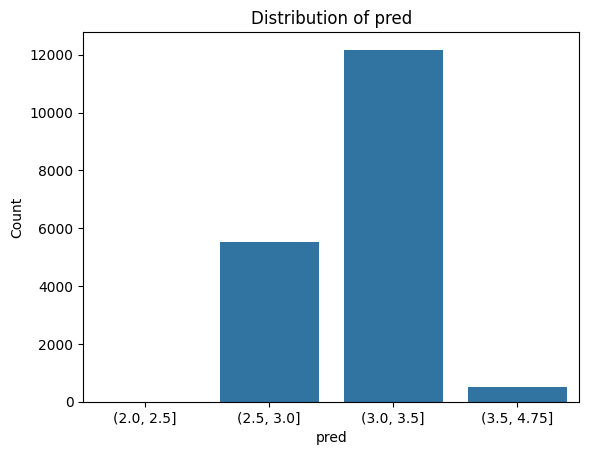

In [37]:
import seaborn as sns

results_df["pred_group"] = pd.cut(results_df["pred"], bins=ATTENTION_BINS)
plt.figure()
sns.countplot(x='pred_group', data=results_df)
plt.title("Distribution of pred")
plt.xlabel("pred")
plt.ylabel("Count")
plt.show()

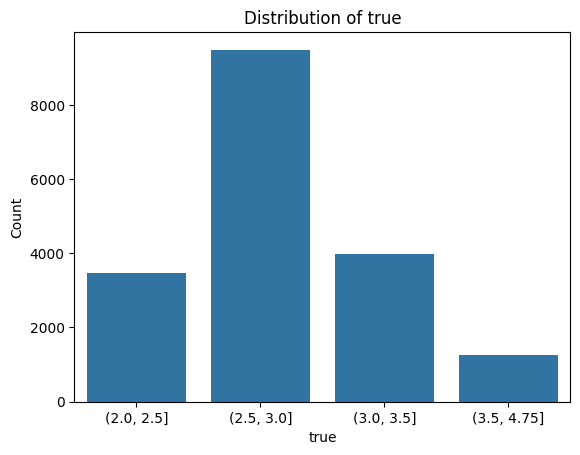

In [38]:
results_df["true_group"] = pd.cut(results_df["true"], bins=ATTENTION_BINS)
plt.figure()
sns.countplot(x='true_group', data=results_df)
plt.title("Distribution of true")
plt.xlabel("true")
plt.ylabel("Count")
plt.show()

In [39]:
from sklearn.metrics import r2_score

print(r2_score(results_df['true'], results_df['pred']))

-0.029880063318439953


In [40]:
results_df.groupby("true_group").agg(
    count=("true", "size"),
    true_mean=("true", "mean"),
    pred_mean=("pred", "mean"),
    pred_min=("pred", "min"),
    pred_max=("pred", "max"),
)

/scratch-local/cfragkiadakis.23092695/ipykernel_1704382/536613243.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby("true_group").agg(


,count,true_mean,pred_mean,pred_min,pred_max
true_group,,,,,
"(2.0, 2.5]",3471,2.431648,3.092426,2.620448,3.571291
"(2.5, 3.0]",9484,2.865748,3.051624,2.619658,3.630518
"(3.0, 3.5]",3983,3.307683,3.179930,2.607466,3.626566
"(3.5, 4.75]",1254,3.912081,3.328197,2.726155,3.628078


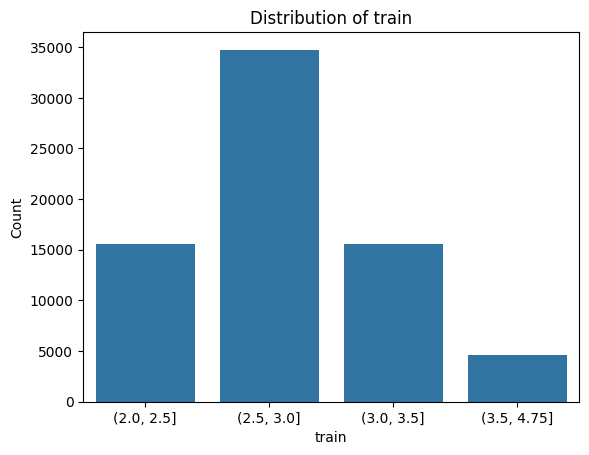

In [41]:
import seaborn as sns
tst = train_df.copy()
tst["train_group"] = pd.cut(tst["target"], bins=ATTENTION_BINS)
plt.figure()
sns.countplot(x='train_group', data=tst)
plt.title("Distribution of train")
plt.xlabel("train")
plt.ylabel("Count")
plt.show()

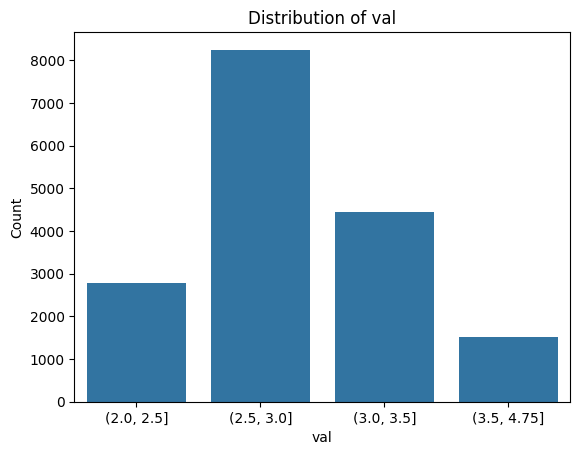

In [42]:
tst = val_df.copy()
tst["val_group"] = pd.cut(tst["target"], bins=ATTENTION_BINS)
plt.figure()
sns.countplot(x='val_group', data=tst)
plt.title("Distribution of val")
plt.xlabel("val")
plt.ylabel("Count")
plt.show()

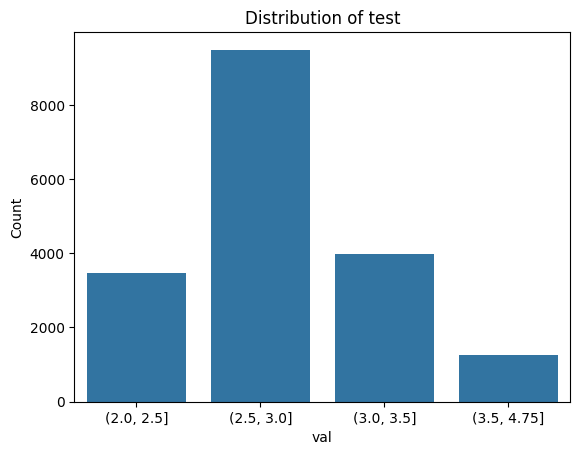

In [43]:
tst = test_df.copy()
tst["test_group"] = pd.cut(tst["target"], bins=ATTENTION_BINS)
plt.figure()
sns.countplot(x='test_group', data=tst)
plt.title("Distribution of test")
plt.xlabel("val")
plt.ylabel("Count")
plt.show()

In [44]:
evaluation_metrics = compute_prediction_metrics(results_df)

mae = evaluation_metrics["mae"]
rmse = evaluation_metrics["rmse"]
tolerant_acc = evaluation_metrics["tolerant_accuracy"]
one_off_acc = evaluation_metrics["one_off_accuracy"]
binary_acc = evaluation_metrics["binary_accuracy"]
binary_f1 = evaluation_metrics["binary_f1"]
binary_auc = evaluation_metrics["binary_roc_auc"]

pd.Series(evaluation_metrics)

n_samples                                         18222
mae                                              0.3181
rmse                                             0.4102
r2                                              -0.0299
tolerant_accuracy                                0.3219
tolerance                                          0.15
one_off_accuracy                                 0.9993
binary_threshold                                    3.0
binary_accuracy                                  0.5816
binary_f1                                        0.6583
binary_roc_auc                                   0.6468
binary_confusion_matrix    [[3254, 5340], [2284, 7344]]
true_mean                                        2.9502
pred_mean                                        3.1066
dtype: object

In [45]:
binary_acc

0.5816

In [46]:
tolerant_acc

0.3219

In [47]:
one_off_acc

0.9993

In [48]:
binary_f1

0.6583

In [49]:
binary_auc

0.6468

In [50]:
name

'245.fusion_split_hr_transformer_mse_clip_vitl14_features_seq10_weighted_loss_a0.5'

In [2]:
experiment_log_csv = os.path.join("results/Multimodal Fusion", "experiment_log.csv")

if os.path.exists(experiment_log_csv):
    experiment_log = pd.read_csv(experiment_log_csv)
    display(experiment_log.sort_values("created_at", ascending=False).reset_index(drop=True))
else:
    print(f"No experiment log found yet: {experiment_log_csv}")

,run_id,experiment_name,created_at,mae,rmse,tolerant_accuracy,binary_accuracy,binary_f1,binary_roc_auc,one_off_accuracy,r2,loss_type,cnn_features,sequence_length,use_weighted_loss,use_weighted_sampler,weight_alpha,best_epoch,training_time_sec,latency_per_sample_ms,gender_worst_group_mae,gender_gap,gender_mae_per_group,age_worst_group_mae,age_gap,age_mae_per_group,stratify
0,20260524_194552,245.fusion_split_hr_transformer_mse_clip_vitl14_features_seq10_weighted_loss_a0.5,2026-05-24 19:45:52,0.3181,0.4102,0.3219,0.5816,0.6583,0.6468,0.9993,-0.0299,mse,clip_vitl14_features,10,True,False,0.5,17,875.26,0.1161,0.32263,0.03644,"{""female"": 0.32263, ""male"": 0.2862}",0.41408,0.17209,"{""(13, 17]"": NaN, ""(17, 20]"": 0.41408, ""(20, 22]"": 0.31802, ""(22, 26]"": 0.24802, ""(26, 44]"": 0.242}",age_group
1,20260524_182802,245.fusion_split_hr_transformer_mse_clip_vitl14_features_seq10_weighted_loss_a0.5,2026-05-24 18:28:02,0.3529,0.4317,0.2294,0.6188,0.7584,0.6008,0.9991,-0.0533,mse,clip_vitl14_features,10,True,False,0.5,13,831.02,0.1155,0.35481,0.00708,"{""female"": 0.35481, ""male"": 0.34774}",0.41544,0.15737,"{""(13, 17]"": 0.25807, ""(17, 20]"": 0.41544, ""(20, 22]"": 0.36308, ""(22, 26]"": 0.36167, ""(26, 44]"": 0.34782}",NaN
2,20260524_140241,245.fusion_split_hr_transformer_smooth_l1_clip_vitl14_features_seq10_weighted_loss_a0.5,2026-05-24 14:02:41,0.3189,0.4020,0.3106,0.6466,0.7631,0.6166,0.9988,0.0864,smooth_l1,clip_vitl14_features,10,True,False,0.5,24,1195.42,0.1166,0.33021,0.01554,"{""female"": 0.31467, ""male"": 0.33021}",0.34787,0.11614,"{""(13, 17]"": 0.23173, ""(17, 20]"": 0.34478, ""(20, 22]"": 0.33354, ""(22, 26]"": 0.34787, ""(26, 44]"": 0.29238}",NaN
3,20260524_130818,245.fusion_split_hr_transformer_smooth_l1_clip_vitl14_features_seq5_weighted_loss_a0.5,2026-05-24 13:08:18,0.3571,0.4342,0.2352,0.6238,0.7683,0.5772,0.9995,-0.0676,smooth_l1,clip_vitl14_features,5,True,False,0.5,10,687.96,0.1164,0.36041,0.00461,"{""female"": 0.3558, ""male"": 0.36041}",0.37923,0.11615,"{""(13, 17]"": 0.26308, ""(17, 20]"": 0.37923, ""(20, 22]"": 0.36685, ""(22, 26]"": 0.37007, ""(26, 44]"": 0.37341}",NaN
4,20260524_042101,245.fusion_split_hr_transformer_smooth_l1_2clip_vitl14_features_seq10_weighted_loss_a0.5,2026-05-24 04:21:01,0.3006,0.3814,0.3401,0.6279,0.7361,0.6352,0.9992,0.1776,smooth_l1,2clip_vitl14_features,10,True,False,0.5,21,1121.65,0.1295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
